In [6]:
from brian2 import * #do not forget to load this each time to not get unit errors.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import import_ipynb

from param import *
import trains
import traces

In [8]:
%matplotlib inline

In [9]:
#print(phi)

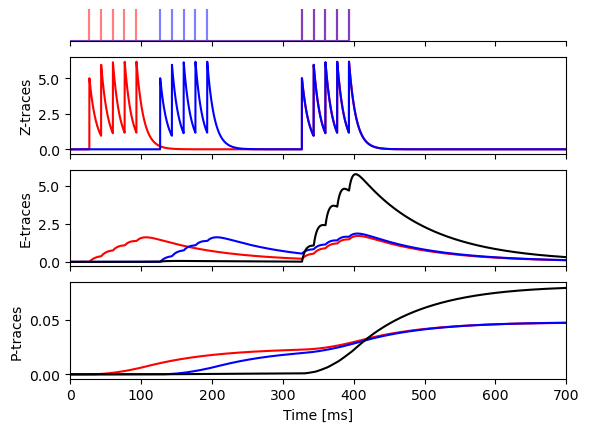

In [24]:
# Neuron model, defining equations:

defaultclock.dt = s_dt

N_total = 3
 
min_num = 10e-6

#dI, sim

phi = 0 * pA #50 * pA

dI = -0.3 * nA #0.5
stimulation_protocol = TimedArray(np.transpose([
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
]), dt=100*ms)

eqs_neurons = '''

# Memory traces for postsynaptic neuron j: 

dS_j/dt = -S_j/s_dt : 1
dZ_j/dt = (S_j / (f_max * t_spike) - Z_j + epsilon * second ) / tau_z : 1
dE_j/dt = (Z_j - E_j) / tau_e : 1
dP_j/dt = (kappa * (E_j - P_j)) / tau_p : 1

# Bias 
beta = log(clip(P_j, min_num, inf)) : 1 # beta = log(P_j), but if P_j < min_num, clip sets P_j <- min_num.
I_beta = phi * beta : amp # written as phi_{I beta} in the paper, but should actually be I_beta.

# On-switch: 
b_on = stimulation_protocol(t, i) : 1
I_on = b_on * dI : amp

# Total voltage:
g_ex : siemens # sum for all excitatory synapses
g_inh : siemens # sum for all inhibitory synapses


# LIF Neuron Model:

dV/dt = (g_L * (V - E_L) + g_ex * (V - E_ex) + g_inh * (V - E_inh) + I_beta + I_on) / - C_m : volt (unless refractory)

'''
# Added I_on now

neurons = NeuronGroup(N_total, model = eqs_neurons, method = 'euler', threshold = 'V >= V_th', reset = 'V = V_res', refractory = t_ref)
neurons.V = -70 * mV # leak reversal potential

#excitatory & inhibitory conductance
rec_syn_model = '''

b_ex : 1 # = excitatory: 1, inhibitory: 0.
w_g = w * g_max : siemens # weighted maximum conductance 

dS_ex/dt = -S_ex / tau_ex : 1 (clock-driven) # excitatory conducting window
dalpha_ex/dt = (S_ex - alpha_ex ) / tau_ex : 1 (clock-driven) 
g_ex_post = b_ex * w_g * alpha_ex : siemens (summed) 

dS_inh/dt = -S_inh/tau_inh : 1 (clock-driven) #inhibitory conducting window
dalpha_inh/dt = (S_inh - alpha_inh) / tau_inh : 1 (clock-driven)
g_inh_post = (1 - b_ex) * w_g * alpha_inh : siemens (summed)

# Presynaptic (i) traces
dS_i/dt = -S_i /s_dt : 1 (clock-driven)
dZ_i/dt = (S_i / (f_max * t_spike) - Z_i + epsilon * second) / tau_z : 1 (clock-driven)
dE_i/dt = (Z_i - E_i) / tau_e : 1 (clock-driven)
dP_i/dt = (kappa * (E_i - P_i)) / tau_p : 1 (clock-driven)

# BCPNN synapse
dE_syn/dt = (Z_i * Z_j_post - E_syn) / tau_e : 1 (clock-driven)
dP_syn/dt = (kappa * (E_syn - P_syn)) / tau_p : 1 (clock-driven)
w = log(clip(P_syn, min_num, inf) / clip(P_i * P_j_post, min_num, inf)) : 1 (constant over dt)
'''

rec_syn_on_pre = '''
S_i = 1
S_ex =  1
S_inh = 1
'''

rec_syn_on_post = '''
S_j_post = 1
'''

S_neurons = Synapses(neurons, neurons, model = rec_syn_model, on_pre = rec_syn_on_pre, on_post = rec_syn_on_post, method = 'euler', delay = d)
S_neurons.connect(condition = 'i != j')
S_neurons.b_ex[:] = 1 #'rand() > 0.2'

spikemon = SpikeMonitor(neurons)
statemon = StateMonitor(neurons, ['V', 'S_j', 'Z_j', 'E_j', 'P_j', 'beta', 'g_ex', 'g_inh', 'I_beta', 'I_on'], record=[0, 1])
synmon = StateMonitor(S_neurons, ['w', 'Z_i', 'E_i', 'P_i', 'E_syn', 'P_syn'], record=True)

tfinal = 800 * ms # trying 500 instead of 1 000
run(tfinal)

#plt.plot(statemon.t/ms, statemon.g_ex[0]/nS)
#plt.show

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, sharex=True,
                                     gridspec_kw={'height_ratios': (1, 3, 3, 3)})

#trains.get_full_train(ax, spikemon, N_total)

trains.compare_two_trains(ax1, spikemon, 0, 1)

traces.plot_z_traces(ax2, statemon, synmon, S_neurons, 0, 1)

traces.plot_e_traces(ax3, statemon, synmon, S_neurons, 0, 1)

traces.plot_p_traces(ax4, statemon, synmon, S_neurons, 0, 1)


ax4.set_xticks(np.arange(0, tfinal / ms, 100))
ax4.set_xlabel("Time [ms]")

plt.show()

# synapse model, look at Brian documentation